<div style="border-radius: 15px; border: 2px solid #ffcc00; padding: 20px; background: linear-gradient(135deg, #00bfff, #1e90ff, #11235A); text-align: center; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);">
    <h1 style="color: #ffcc00; text-shadow: 3px 3px 6px rgba(0, 0, 0, 0.7); font-weight: bold; margin-bottom: 10px; font-size: 36px; font-family: 'Press Start 2P', cursive;">
         Player Engagement Analysis & Prediction 
    </h1>
</div>

### **Overview: Predict Online Gaming Behavior**
This dataset provides a detailed view of player behavior and demographics in **online gaming environments**. It includes a variety of features that capture key aspects of gaming activity, player characteristics, and engagement levels, making it an excellent resource for analyzing player retention and predicting engagement patterns.

#### **Features:**
   - **PlayerID**: Unique identifier for each player.
   - **Age**: Age of the player.
   - **Gender**: Gender of the player.
   - **Location**: Geographic location of the player.
   - **GameGenre**: Genre of the game the player is engaged in (e.g., RPG, Strategy, Action).
   - **GameDifficulty**: Difficulty level of the game, categorized as Easy, Medium, or Hard.
   - **PlayerLevel**: Current level of the player in the game.
   - **AchievementsUnlocked**: Number of achievements unlocked by the player.
   - **PlayTimeHours**: Average hours spent playing per session.
   - **InGamePurchases**: Indicates whether the player makes in-game purchases (0 = No, 1 = Yes).
   - **SessionsPerWeek**: Number of gaming sessions per week.
   - **AvgSessionDurationMinutes**: Average duration of each gaming session in minutes.

   **Target Variable**:
   - **EngagementLevel**: The target variable categorizes player engagement levels into three classes: 'High', 'Medium', and 'Low', reflecting player retention and activity.

# Imports and Setup

In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

from scipy.stats import randint
import joblib
import warnings
warnings.filterwarnings("ignore")

# Load and Explore Dataset

In [300]:
# Load the dataset
df = pd.read_csv('data.csv')

# Display shape of the dataset
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,No,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,No,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,No,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,Yes,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,No,Medium,2,131,95,37,Medium


In [301]:
df.tail()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
40029,49029,32,Male,USA,Strategy,20.619662,No,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,No,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,Yes,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,Yes,Medium,3,128,70,10,Medium
40033,49033,19,Male,USA,Sports,10.083804,No,Easy,13,84,72,39,Medium


In [302]:
df.sample(10)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
35371,44371,28,Male,Europe,Simulation,15.675346,Yes,Hard,8,45,73,3,Medium
17510,26510,41,Male,Asia,Sports,23.706260,No,Hard,13,109,77,46,High
16693,25693,43,Male,USA,Simulation,15.712551,No,Easy,13,10,34,44,Low
17688,26688,38,Male,Europe,Sports,23.361336,No,Medium,18,23,77,44,Medium
35353,44353,22,Male,USA,Action,12.714964,No,Easy,4,151,21,42,Medium
35248,44248,21,Male,USA,Simulation,19.061612,No,Hard,2,168,35,42,Medium
22035,31035,34,Female,Europe,RPG,8.990609,No,Easy,10,128,88,33,High
16339,25339,30,Female,Europe,Strategy,15.975207,Yes,Medium,14,89,7,22,Medium
36065,45065,18,Male,Asia,RPG,17.632787,No,Hard,0,137,72,33,Low
32610,41610,23,Male,Other,RPG,21.484254,No,Easy,3,44,32,31,Medium


In [303]:
# Display basic information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  object 
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(6), 

In [304]:
# Display statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,PlayerID,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,32.297897,12.080785,9.471774,95.607733,49.655568,24.526477
std,11556.964675,10.940344,7.101999,5.763667,51.245715,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,14.000000,137.000000,74.000000,37.000000
max,49033.000000,82.000000,50.415000,19.000000,300.000000,99.000000,49.000000


In [305]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

Number of duplicate rows: 0


# Unique Value Exploration

In [307]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("Numerical Columns:\n", numerical_columns)
print("\nCategorical Columns:\n", non_numerical_columns)

Numerical Columns:
 ['PlayerID', 'Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

Categorical Columns:
 ['Gender', 'Location', 'GameGenre', 'InGamePurchases', 'GameDifficulty', 'EngagementLevel']


In [308]:
# Display the number of unique values in each column
cat_columns = df.select_dtypes(include=['object'])
unique_values = cat_columns.nunique()
print("Number of unique values in each column:")
print(unique_values)

Number of unique values in each column:
Gender             2
Location           4
GameGenre          5
InGamePurchases    2
GameDifficulty     3
EngagementLevel    3
dtype: int64


In [309]:
# Display unique values for each categorical column
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].unique()}")


Column: Gender
Unique Values: ['Male' 'Female']

Column: Location
Unique Values: ['Other' 'USA' 'Europe' 'Asia']

Column: GameGenre
Unique Values: ['Strategy' 'Sports' 'Action' 'RPG' 'Simulation']

Column: InGamePurchases
Unique Values: ['No' 'Yes']

Column: GameDifficulty
Unique Values: ['Medium' 'Easy' 'Hard']

Column: EngagementLevel
Unique Values: ['Medium' 'High' 'Low']


# Exploratory Data Analysis (EDA)

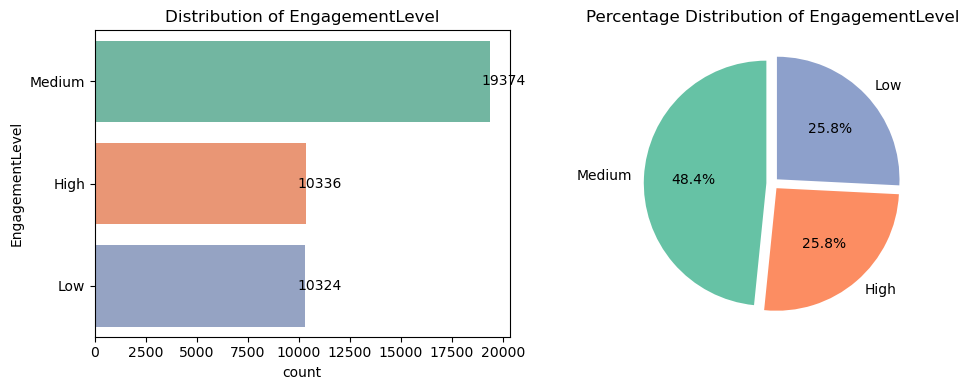

In [311]:
column_name = 'EngagementLevel'
plt.figure(figsize=(10, 4))

# First subplot: Count plot
plt.subplot(1, 2, 1)
sns.countplot(y=column_name, data=df, palette='Set2')  
plt.title(f'Distribution of {column_name}')

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', xytext=(10, 0), textcoords='offset points')


# Second subplot: Pie chart
plt.subplot(1, 2, 2)
df[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90, explode=[0.05]*df[column_name].nunique())
plt.title(f'Percentage Distribution of {column_name}')
plt.ylabel('')  

plt.tight_layout()
plt.show()

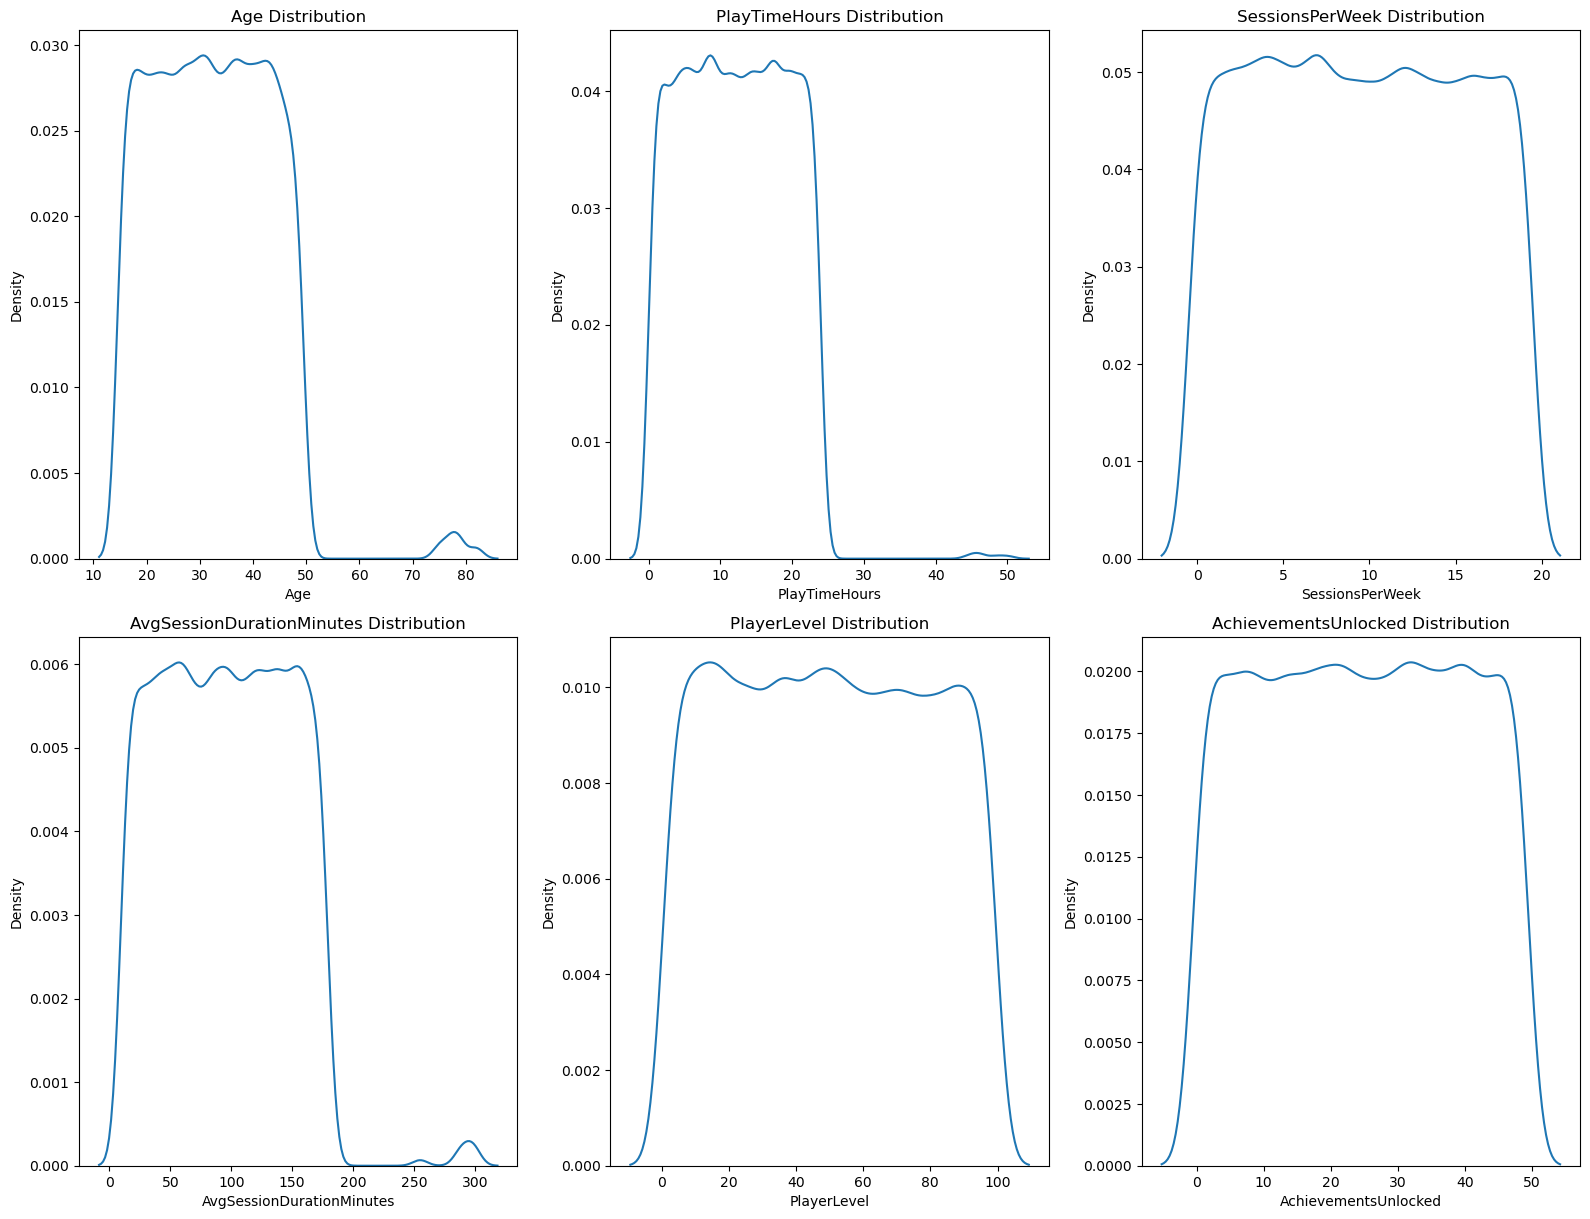

In [312]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(16, 24))  
    
    for i, column in enumerate(columns):
        plt.subplot(4, 3, i + 1)  
        sns.kdeplot(data[column])
        plt.title(f'{column} Distribution')
        plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

# Columns to analyze
columns_to_analyze = [
    'Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked'
]

# Perform univariate analysis
univariate_analysis(df, columns_to_analyze)

In [313]:
# Select only numerical columns
numerical_df = df.select_dtypes(include="number")

# Calculate skewness 
skewness = numerical_df.skew()

display("Skewness:", skewness)


'Skewness:'

PlayerID                     0.000000
Age                          0.640356
PlayTimeHours                0.253437
SessionsPerWeek              0.015517
AvgSessionDurationMinutes    0.313618
PlayerLevel                  0.018754
AchievementsUnlocked        -0.005136
dtype: float64

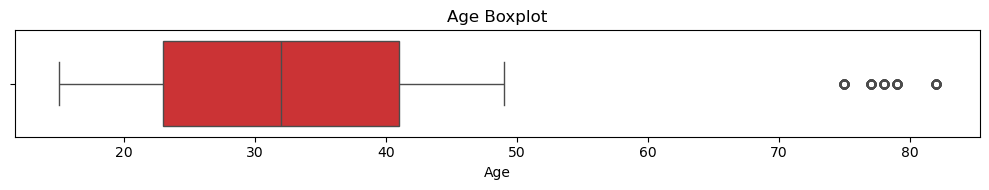


Five number Summary for Age:
Q1: 23.0
Q2: 32.0
Q3: 41.0
IQR: 18.0
Upper Bound: 68.0
Lower Bound: -4.0


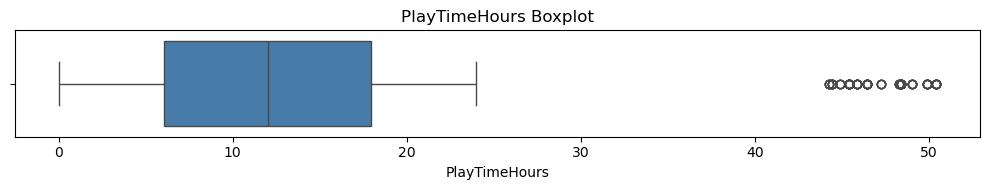


Five number Summary for PlayTimeHours:
Q1: 6.067500507750126
Q2: 12.00800215801307
Q3: 17.963831138295756
IQR: 11.89633063054563
Upper Bound: 35.8083270841142
Lower Bound: -11.776995438068319


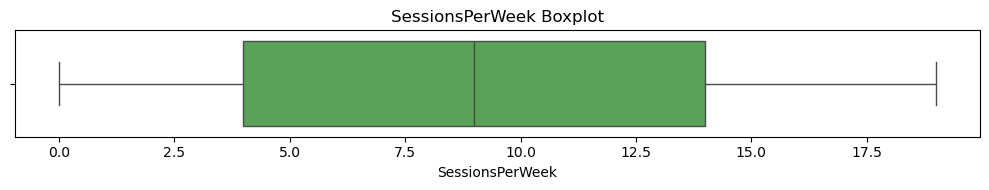


Five number Summary for SessionsPerWeek:
Q1: 4.0
Q2: 9.0
Q3: 14.0
IQR: 10.0
Upper Bound: 29.0
Lower Bound: -11.0


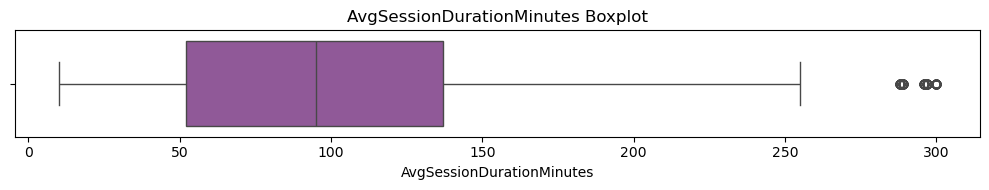


Five number Summary for AvgSessionDurationMinutes:
Q1: 52.0
Q2: 95.0
Q3: 137.0
IQR: 85.0
Upper Bound: 264.5
Lower Bound: -75.5


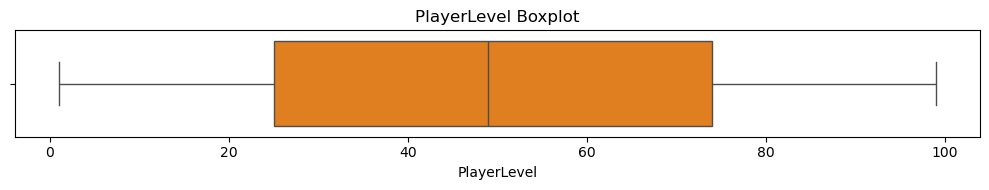


Five number Summary for PlayerLevel:
Q1: 25.0
Q2: 49.0
Q3: 74.0
IQR: 49.0
Upper Bound: 147.5
Lower Bound: -48.5


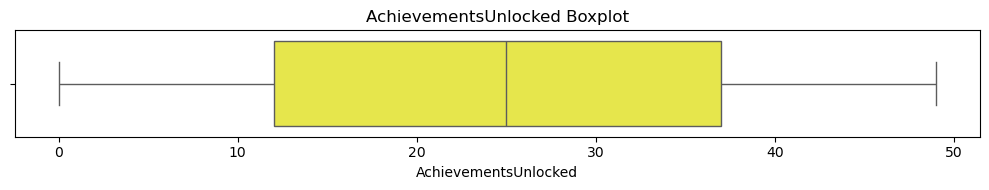


Five number Summary for AchievementsUnlocked:
Q1: 12.0
Q2: 25.0
Q3: 37.0
IQR: 25.0
Upper Bound: 74.5
Lower Bound: -25.5


In [314]:
# Function to perform univariate analysis for numeric columns with boxplots and statistics
def univariate_analysis(data, column):
    plt.figure(figsize=(10, 2))
    
    color = sns.color_palette("Set1")[columns_to_analyze.index(column) % len(sns.color_palette("Set1"))]
    sns.boxplot(x=data[column], color=color)
    plt.title(f'{column} Boxplot')
    plt.tight_layout()
    plt.show()

    q1 = data[column].quantile(0.25)
    q2 = data[column].quantile(0.50)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr

    print(f'\nFive number Summary for {column}:')
    print(f'Q1: {q1}')
    print(f'Q2: {q2}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Upper Bound: {upper_bound}')
    print(f'Lower Bound: {lower_bound}')

# Columns to analyze
columns_to_analyze = [
    'Age', 'PlayTimeHours', 'SessionsPerWeek', 
    'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked'
]

for column in columns_to_analyze:
    univariate_analysis(df, column)


# Data Preprocessing

In [316]:
# Handling outliers from columns
outlier_columns = ["Age", "PlayTimeHours", "AvgSessionDurationMinutes"]

for col in outlier_columns:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    df.loc[df[col] > upper_bound, col] = q3

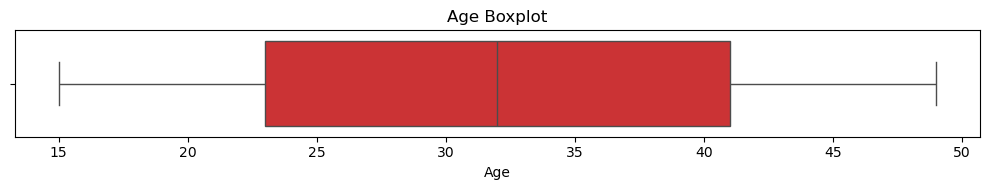

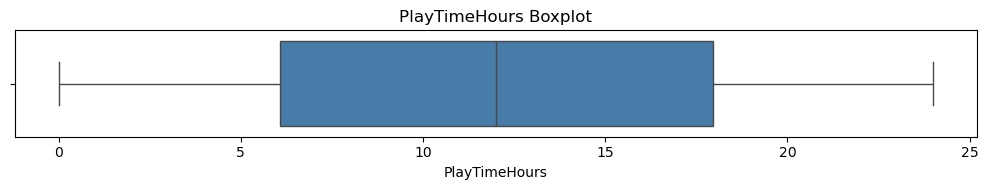

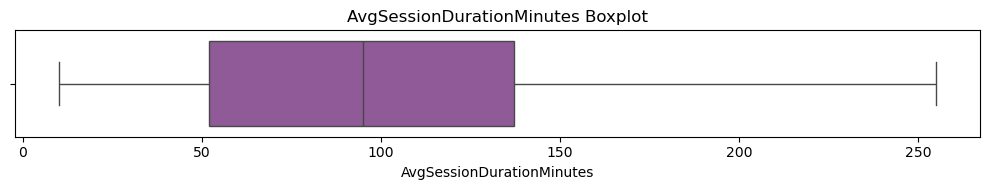

In [317]:
for column in outlier_columns:
    plt.figure(figsize=(10, 2))
    
    color = sns.color_palette("Set1")[columns_to_analyze.index(column) % len(sns.color_palette("Set1"))]
    sns.boxplot(x=df[column], color=color)
    plt.title(f'{column} Boxplot')
    plt.tight_layout()
    plt.show()

In [318]:
df[outlier_columns].skew()

Age                         -0.016840
PlayTimeHours               -0.005962
AvgSessionDurationMinutes    0.011950
dtype: float64

### Encode Categorical Features

1. **Gender**: Binary Encoding: `Male = 1`, `Female = 0`.
2. **InGamePurchases**: Binary Encoding: `Yes = 1`, `No = 0`.
3. **Location**: One-Hot Encoding: Adds columns like `Location_Europe`, `Location_Other`, `Location_USA`.
4. **GameGenre**: One-Hot Encoding: Adds columns like `Genre_Action`, `Genre_RPG`, `Genre_Simulation`.
5. **GameDifficulty**: Ordinal Encoding: Maps `Easy = 1`, `Medium = 2`, `Hard = 3`.
6. **EngagementLevel**: Ordinal Encoding: Maps `Low = 1`, `Medium = 2`, `High = 3`.

In [320]:
def encode_categorical_features(df):
    # Encode Gender using Label Encoding
    df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})

    # Encode InGamePurchases using Label Encoding
    df['InGamePurchases'] = df['InGamePurchases'].replace({'No': 0, 'Yes': 1})
    
    # Encode Location using One-Hot Encoding
    df = pd.get_dummies(df, columns=['Location'], drop_first=True, dtype='int',prefix='Location')
    
    # Encode GameGenre using One-Hot Encoding
    df = pd.get_dummies(df, columns=['GameGenre'], drop_first=True, dtype='int', prefix='Genre')
    
    # Encode GameDifficulty using Ordinal Encoding 
    difficulty_mapping = {'Easy': 0, 'Medium': 1, 'Hard': 2}
    df['GameDifficulty'] = df['GameDifficulty'].map(difficulty_mapping)
    
    # Encode EngagementLevel using Ordinal Encoding 
    engagement_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df['EngagementLevel'] = df['EngagementLevel'].map(engagement_mapping)
    
    return df

# Apply the function to the DataFrame
encoded_data = encode_categorical_features(df)

# Display the first few rows of the encoded DataFrame
encoded_data.head()


,PlayerID,Age,Gender,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Europe,Location_Other,Location_USA,Genre_RPG,Genre_Simulation,Genre_Sports,Genre_Strategy
0,9000,43,0,16.271119,0,1,6,108,79,25,1,0,1,0,0,0,0,1
1,9001,29,1,5.525961,0,1,5,144,11,10,1,0,0,1,0,0,0,1
2,9002,22,1,8.223755,0,0,16,142,35,41,2,0,0,1,0,0,1,0
3,9003,35,0,5.265351,1,0,9,85,57,47,1,0,0,1,0,0,0,0
4,9004,33,0,15.531945,0,1,2,131,95,37,1,1,0,0,0,0,0,0


In [321]:
encoded_data.shape

(40034, 18)

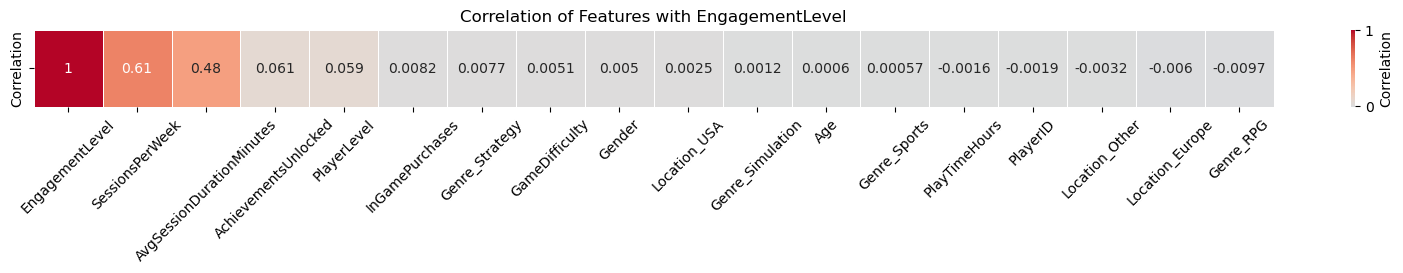

In [322]:
# Calculate correlations with EngagementLevel
correlations_with_EngagementLevel_1 = encoded_data.corr()['EngagementLevel'].sort_values(ascending=False)

correlation_df = correlations_with_EngagementLevel.to_frame(name='Correlation').T

plt.figure(figsize=(20, 1))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation of Features with EngagementLevel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [323]:
# Drop PlayerID as it's not a predictive feature
encoded_data = encoded_data.drop(columns=['PlayerID'])

# Train Test Split

In [325]:
# Define features and target
X = encoded_data.drop(columns=['EngagementLevel']) 
y = encoded_data['EngagementLevel'] 

In [326]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the splits for verification
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")


Training Features Shape: (32027, 16)
Testing Features Shape: (8007, 16)
Training Target Shape: (32027,)
Testing Target Shape: (8007,)


In [350]:
# Apply Scaler to standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation

In [352]:
# Model Initialization
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight = 'balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100,random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, class_weight = 'balanced'),
}


# Display model names to confirm initialization
print("Models initialized:", list(models.keys()))

Models initialized: ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'XGBoost', 'LightGBM']


In [360]:
# Dictionary to store results for comparison
results = {'Model': [], 'Testing Accuracy': [], 'Training Accuracy': [],'F1-Score (Macro)': []}

# Loop through models to train, predict, and evaluate
print("--- Starting Model Training and Evaluation ---")
print("==============================================")

for name, model in models.items():
    
    # Training the model
    model.fit(X_train_scaled, y_train)
    
    # Prediction on the test & train set
    y_test_pred = model.predict(X_test_scaled)
    y_train_pred = model.predict(X_train_scaled)
    
    # Evaluation
    test_acc = accuracy_score(y_test, y_test_pred)
    train_acc = accuracy_score(y_train, y_train_pred)
    report = classification_report(y_test, y_test_pred, output_dict=True)
    f1_macro = report['macro avg']['f1-score']
    
    # Store results
    results['Model'].append(name)
    results['Testing Accuracy'].append(test_acc)
    results['Training Accuracy'].append(train_acc)
    results['F1-Score (Macro)'].append(f1_macro)
    
    # Print detailed report for each model
    print(f"\n Model: {name}")
    print(f"   Training Accuracy: {train_acc:.4f}")
    print(f"   Testing Accuracy: {test_acc:.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print("----------------------------------------------")

# Display a final comparison table
results_df = pd.DataFrame(results).sort_values(by='Testing Accuracy', ascending=False)
print("\n--- Final Model Comparison ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

--- Starting Model Training and Evaluation ---

 Model: Decision Tree
   Training Accuracy: 1.0000
   Testing Accuracy: 0.8330

   Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      2065
           1       0.87      0.86      0.87      3875
           2       0.80      0.82      0.81      2067

    accuracy                           0.83      8007
   macro avg       0.82      0.82      0.82      8007
weighted avg       0.83      0.83      0.83      8007

----------------------------------------------

 Model: Random Forest
   Training Accuracy: 1.0000
   Testing Accuracy: 0.9132

   Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      2065
           1       0.91      0.95      0.93      3875
           2       0.93      0.88      0.90      2067

    accuracy                           0.91      8007
   macro avg       0.92      0.90      

# Hyper Parameter Tunning

### 1. GridSearchCV for Decision Tree

In [364]:
# Define the Parameter Grid
param_grid = {
    'max_depth': [5, 8, 12, 15],              
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize the base model
dt = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

# Fit the search to the data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and score
best_dt_model = grid_search.best_estimator_
print(f"Best Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Best Score: 0.9055
Best Parameters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 2}


### 2. RandomizedSearchCV for Random Forest

In [161]:
# Define the Parameter Distribution
param_dist = {
    'n_estimators': randint(50, 150),         
    'max_depth': randint(5, 15),              
    'min_samples_leaf': randint(1, 10),      
    'criterion': ['gini', 'entropy']
}

# Initialize the base model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,                      
    cv=5,                            
    random_state=42,
    n_jobs=-1                       
)

# Fit the search to the data
random_search.fit(X_train, y_train)

# Get the best parameters and score
best_rf_model = random_search.best_estimator_
print(f"Best Score : {random_search.best_score_:.4f}")
print(f"Best Parameters: {random_search.best_params_}")

Best Score : 0.9053
Best Parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 4, 'n_estimators': 103}


### 3. RandomizedSearchCV for XGBoost

In [163]:
# Define the Parameter Distribution
xgb_param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': randint(1, 10),
    'subsample': [0.7, 0.8, 0.9, 1.0],
}

# Initialize the base model
xgb = XGBClassifier(random_state=42)

# Initialize RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=50,                        
    cv=5,                         
    random_state=42,
    n_jobs=-1
)

# Fit the search to the data
xgb_random_search.fit(X_train, y_train)
print(f"Best XGBoost Score: {xgb_random_search.best_score_:.4f}")
print(f"Best XGBoost Params: {xgb_random_search.best_params_}")

Best XGBoost Score: 0.9179
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 4, 'n_estimators': 63, 'subsample': 0.9}


### 4. RandomizedSearchCV for AdaBoost

In [165]:
# Define the Parameter Distribution
adaboost_param_dist = {
    'n_estimators': randint(50, 150),
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
}

# Initialize the model with a base estimator
dt_base = DecisionTreeClassifier(random_state=42)
ada = AdaBoostClassifier(estimator=dt_base, random_state=42)

# Initialize RandomizedSearchCV
ada_random_search = RandomizedSearchCV(
    estimator=ada,
    param_distributions=adaboost_param_dist,
    n_iter=50,
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Fit the search to the data 
ada_random_search.fit(X_train, y_train)
print(f"Best AdaBoost Score: {ada_random_search.best_score_:.4f}")
print(f"Best AdaBoost Params: {ada_random_search.best_params_}")

Best AdaBoost Score: 0.8273
Best AdaBoost Params: {'learning_rate': 0.15, 'n_estimators': 101}


### 5. RandomizedSearchCV for LGBM

In [167]:
# Define the search space for LGBM
lgbm_param_dist_discrete = {
    'n_estimators': randint(100, 200),
    'num_leaves': randint(20, 50),
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'feature_fraction': [0.7, 0.8, 0.9, 1.0],
}

# Initialize the model
lgbm = LGBMClassifier(random_state=42)

# Initialize RandomizedSearchCV with limited iterations
lgbm_random_search_discrete = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_dist_discrete,
    n_iter=25,                        
    cv=3,                              
    random_state=42,
    n_jobs=-1                        
)

# Fit the search to the data 
lgbm_random_search_discrete.fit(X_train, y_train)
print(f"Best LGBM Score: {lgbm_random_search_discrete.best_score_:.4f}")
print(f"Best LGBM Params: {lgbm_random_search_discrete.best_params_}")

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 32027, number of used features: 16
[LightGBM] [Info] Start training from score -1.355276
[LightGBM] [Info] Start training from score -0.725804
[LightGBM] [Info] Start training from score -1.354066
Best LGBM Score: 0.9147
Best LGBM Params: {'feature_fraction': 1.0, 'learning_rate': 0.05, 'n_estimators': 159, 'num_leaves': 33}


In [168]:
best_model = xgb_random_search.best_estimator_
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=4, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=63,
              n_jobs=None, num_parallel_tree=None, ...)

In [366]:
df2 = pd.read_csv("data.csv")
df2 = df2.drop('PlayerID', axis=1)
X1 = df2.drop('EngagementLevel', axis=1)
y1 = df2['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y)

outlier_columns = ["Age", "PlayTimeHours", "AvgSessionDurationMinutes"]
for col in outlier_columns:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    df.loc[df[col] > upper_bound, col] = q3

NUMERICAL_FEATURES = [
    'Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked'
]


CATEGORICAL_FEATURES = [
    'Gender', 'Location', 'GameGenre', 'GameDifficulty', 'InGamePurchases'
]


# Create the Preprocessing Pipeline  
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), NUMERICAL_FEATURES),
        ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ],
    remainder='drop',
    n_jobs=-1
)

best_params = {'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 4, 'n_estimators': 63, 'subsample': 0.9}
best_XGmodel = XGBClassifier(random_state=42, **best_params)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_XGmodel)
])

pipeline.fit(X_train1,y_train1)

joblib.dump(pipeline, 'player_engagement_prediction_pipeline.joblib')

print("Successfully saved the full model pipeline to: 'player_engagement_prediction_pipeline.joblib'")

Successfully saved the full model pipeline to: 'player_engagement_prediction_pipeline.joblib'


In [170]:
pipeline.predict(X_test1)

array([1, 2, 1, ..., 2, 1, 1], dtype=int64)